# 1. Downsampling of the global nucleotide sequence dataset grouped by location and year using CD-HIT.

*Objective: To reduce the dataset size to a representative set of sequences while preserving genetic diversity within each spatiotemporal group.*

**Important ❗** The code only supports FASTA headers in the following format: Isolate name | Type | Segment | Collection date | Isolate ID | Clade  | Lineage.

For example: **A/goose/Guangdong/08/2005|A_/_H5N1|HA|2005-01-01|EPI_ISL_138867|2.3.4|**

⚡**Location Parsing Logic:** The location is extracted from the portion of the label following the second "/" delimiter, provided it contains absolutely no digits.

Human Isolates Format: **A/Wyoming/01/2025|A_/_H5N1|HA|02/11/2025|EPI_ISL_19749443|2.3.4.4b|**, In this case, the segment following the second delimiter contains the isolate ID (which includes digits), prompting the script to fall back to the section after the first delimiter. If this section contains no digits, it is accepted as the location. If it does contain digits, the isolate is assigned to the "Unknown" location group and is excluded from the downsampling process.

⚡ **Year Parsing Logic:** The script looks for a 4-digit number positioned immediately BEFORE the first vertical bar delimiter "|". If this value is missing, the script shifts to the section following the third vertical bar delimiter to extract the 4-digit year from there.



**Error Examples:**

Occasionally, the location or year extraction may fail due to specific data inconsistencies (most frequently caused by non-standard delimiters, such as
A_herring_gull_Latvia_287263_21VIR8325-5_2021|A_/_H5N1|HA|2021-05-30|EPI_ISL_18458053|2.3.4.4b|). Such sequences are assigned to the "Unknown" group and are not filtered: "⚪ Unknown_2021 group: skipped (retained unchanged: 3 sequences)". A complete list of these problematic headers is displayed at the end of the execution log.

In the H5N1 dataset spanning 2020–2026, such cases accounted for less than 2% of the total sequence count; however, it is highly recommended to thoroughly cross-check the output data.


In [ ]:
# @markdown ### ⚙️ Environment Setup and Library Imports
run_installation = True  # @param {type:"boolean"}

if run_installation:
    print("Installing required packages...")
    !pip install biopython
    !apt-get install -y cd-hit

    import os
    import re
    import subprocess
    from Bio import SeqIO
    from Bio.Seq import Seq
    from Bio.SeqRecord import SeqRecord

    print("Installation completed successfully!")
else:
    print("Installation skipped.")


In [ ]:
# @markdown ### 📂 File Upload
# @markdown Click the "Choose File" button and select your FASTA file.

from google.colab import files

upload_file = True  # @param {type:"boolean"}

if upload_file:
    uploaded = files.upload()

    # Get the name of the first uploaded file
    input_file = list(uploaded.keys())[0] if uploaded else None

    if input_file:
        print(f"File uploaded successfully: {input_file}")
    else:
        print("No file selected.")


In [ ]:
def cdhit_deduplicate(input_file, threshold, word_size, download_result=False, output_name=None):

    # Check if cd-hit-est is installed in the system
    if subprocess.run(["which", "cd-hit-est"], stdout=subprocess.DEVNULL).returncode != 0:
        print("🛑 Error: cd-hit-est is not installed on this system! Please run: !apt-get install cd-hit")
        return

    if not os.path.exists(input_file):
        print(f"🛑 Error: {input_file} not found!")
        return

    records = list(SeqIO.parse(input_file, "fasta"))
    unknown_headers = []
    grouped_data = {}
    print(f"Step 1: Reading file. Total sequences found: {len(records)}")
    print("Grouping sequences by location and year...")


    for rec in records:
        desc = rec.description.strip()
        location, year = "Unknown", "Unknown"

        # Split the header by the vertical bar delimiter
        main_parts = desc.split('|')
        strain_name = main_parts[0].strip().lstrip('>')

      # Split the label by slashes '/'
        virus_name_parts = [p.strip() for p in strain_name.split('/') if p.strip()]

        if len(virus_name_parts) >= 3:

            # 1. LOCATION SEARCH
            loc_candidate = virus_name_parts[2]

            # If the element after the second slash contains digits, it is likely a human isolate where the location is positioned immediately after the first delimiter.
            if re.search(r'\d', loc_candidate):
                first_slash_elem = virus_name_parts[1]

                # If that section also contains only digits (or is an empty string / special characters with digits)
                if first_slash_elem.isdigit() or re.match(r'^[\d_-]+$', first_slash_elem):
                    location = "Unknown"
                else:
                    location = first_slash_elem
            else:
                # If there are no digits in the second element, process it as usual
                location = loc_candidate

            #2. YEAR SEARCH
            year_candidate = virus_name_parts[-1]
            year_match = re.search(r'(\d{4}|\d{2})', year_candidate)

            if year_match:
                found_digits = year_match.group(1)
                year = found_digits if len(found_digits) == 4 else f"20{found_digits}"

            # Fallback year search in the date block (following the 3rd "|")
            if year == "Unknown" and len(main_parts) >= 4:
                backup_year_match = re.search(r'\b(\d{4})\b', main_parts[3].strip())
                if backup_year_match:
                    year = backup_year_match.group(1)

        # If the location or year could not be determined
        if location == "Unknown" or year == "Unknown":
            unknown_headers.append(rec.description)
            if location == "Unknown":
                location = "Unknown"

        # Replace all suspicious characters with "_" for convenience
        raw_key = f"{location}_{year}"
        key = re.sub(r'[^a-zA-Z0-9_-]', '_', raw_key)
        key = re.sub(r'_+', '_', key).strip('_')

        if key not in grouped_data:
            grouped_data[key] = []
        grouped_data[key].append(rec)

    final_records = []

    print("\nStep 2: Running clustering CD-HIT-EST:")
    for key, group in grouped_data.items():
        if not group:
            continue

        # Create file name variables
        temp_input = f"temp_in_{key}.fasta"
        temp_output = f"temp_out_{key}.fasta"

        # If the group name contains "Unknown", save it as is
        if "Unknown" in key:
            print(f" ⚪ Group {key}: skipped (retained unchanged: {len(group)} sequences.)")
            final_records.extend(group)
            continue

        clean_group = []
        for rec in group:
            raw_seq = str(rec.seq).replace("-", "").upper()
            if len(raw_seq) > 10:
                clean_rec = SeqRecord(Seq(raw_seq), id=rec.id, description="")
                clean_group.append(clean_rec)

        if not clean_group:
            print(f" ⚠️ Group {key}: error, check your FASTA alignment")
            continue

        # Write the cleaned group to a temporary file
        SeqIO.write(clean_group, temp_input, "fasta")

        # List of arguments
        cmd = [
            "cd-hit-est",
            "-i", temp_input,
            "-o", temp_output,
            "-c", str(threshold),
            "-n", str(word_size),
            "-d", "0",
            "-M", "0",
            "-T", "0"
        ]

        result = subprocess.run(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)

        # Check if the output file was created successfully
        if os.path.exists(temp_output) and os.path.getsize(temp_output) > 0:

            # Read the IDs selected as unique by CD-HIT
            unique_ids = {rec.id for rec in SeqIO.parse(temp_output, "fasta")}

            # Find these records within the source data and add them to the final results
            cleaned_group = [rec for rec in group if rec.id in unique_ids]
            final_records.extend(cleaned_group)

            if len(cleaned_group) < len(clean_group):
                print(f" 🟢 Group {key}: downsampled (was {len(clean_group)}, became {len(cleaned_group)})")
            else:
                print(f" ⚪ Group {key}: unchanged (retained: {len(clean_group)})")
        else:

            final_records.extend(clean_group)
            stdout_text = result.stdout.decode('utf-8', errors='ignore')
            stderr_text = result.stderr.decode('utf-8', errors='ignore')
            log_error = stderr_text.strip() or stdout_text.strip()[:50]
            print(f" ⚠️ Group {key}: error CD-HIT ({len(clean_group)} sequences.) | Log: {log_error}")

       # Clean up temporary files
        for f in [temp_input, temp_output, f"{temp_output}.clstr"]:
            if os.path.exists(f):
                os.remove(f)
    if unknown_headers:
        print(f"⚠️ DETECTED {len(unknown_headers)} SEQUENCES WITH UNDETERMINED LOCATION/YEAR (retained unchanged):")

    for header in unknown_headers:
        print(f" • {header}")

       # If the name is not specified, generate it automatically
    if not output_name:
        base_name = os.path.splitext(os.path.basename(input_file))[0]
        output_name = f"{len(final_records)}__{base_name}.fasta"
    else:
        # Add .fasta if it is missing from the file name
        if not output_name.endswith('.fasta') and not output_name.endswith('.fa'):
            output_name = output_name + '.fasta'

    SeqIO.write(final_records, output_name, "fasta")
    print(f"\n SUMMARY: {len(final_records)} ✅ sequences successfully processed and saved to {output_name}")

    if download_result:
        from google.colab import files
        print(f"file downloading {output_name}...)")
        files.download(output_name)

        #интерфейс:

#@markdown ☘️ Enter the name of your FASTA file and select the identity threshold:
input_file = "" #@param {type:"string"}
threshold = 0.995 #@param {type:"slider", min:0.9, max:1.0, step:0.001}

#@markdown Enter the output file name (if left empty, the name will be formatted as "number of sequences after filtering__original name")
output_name = ""  # @param {type:"string"}

# downloading:
download_results_automatically = True #@param {type:"boolean"}


word_size = 9 #@param [5, 6, 7, 8, 9, 10, 11] {type:"raw"}
#@markdown *Please refer to the cdhit-users-guide.pdf to select the appropriate word length.

cdhit_deduplicate(
    input_file=input_file,
    threshold=threshold,
    word_size=word_size,
    download_result=download_results_automatically,
    output_name=output_name
)

### 2. Visualizing Locations on the World Map 🗺️
**Objective:** To determine the circulation zones of the identified lineages/clusters.

***Once you have constructed a phylogenetic tree using the downsampled dataset and identified specific phylogeographic clusters, you can visualize the geospatial data on a world map.***

The following cell allows you to extract a list of locations from a sequence label list copied from any source.

*Note: Each label must start with the virus type designation followed by a slash (e.g., "A/"). The location extraction logic follows the same criteria as Step 1: the script extracts the section after the second slash, provided it contains absolutely no digits. If this section includes digits, the algorithm falls back to the segment after the first slash. If both sections contain digits, the script outputs the full label of the isolate for manual verification.*


In [ ]:
#@markdown **Exporting the location list from a cluster (JSON format)** { display-mode: "form" }
import json
import re

#@markdown Copy all sequence labels of the identified cluster (e.g., from MEGA) and paste them below:
raw_data = "" #@param {type:"string", widget:"textarea"}

# 1. Dropdown list to select the Influenza type:
virus_type = "A" # @param ["A","B","C","D"]
#@markdown Specify the Influenza virus type in the virus_type field; this is required for the algorithm to function correctly.

def extract_locations(text):
    locations = set()

    # 2. Apply the selected Influenza type
    lines = re.findall(rf'({virus_type}/.*?)(?={virus_type}/|$)', text)
    locations = set()
    bad_locations_lines = []  # List for full labels with invalid locations (containing at least one digit)


    for line in lines:
        cleaned_line = line.strip()
        if not cleaned_line:
            continue

# 1. Extract the isolate name before the first vertical bar '|'
        name_part = cleaned_line.split('|')[0].strip()
        parts = [p.strip() for p in name_part.split('/') if p.strip()]

        if len(parts) >= 3:
            # Candidate #1: the element after the second slash (index 2)
            loc_candidate = parts[2]

            # If the element after the second slash contains at least one digit
            if re.search(r'\d', loc_candidate):
                final_loc = parts[1]

                # If the element after the first slash also contains at least one digit
                if re.search(r'\d', final_loc):
                    bad_locations_lines.append(cleaned_line)
                    continue
            else:
                final_loc = loc_candidate

            # 2. Add only text-based locations to the final list
            if final_loc:
                locations.add(final_loc)

    cities_list = sorted(list(locations))

    # Return the JSON string and the error list for output
    return json.dumps(cities_list, ensure_ascii=False), bad_locations_lines


# output:
json_result, bad_lines = extract_locations(raw_data)

print(json_result)

if bad_lines:
    print(f"\n⚠️ List of labels from which the location could not be extracted:")
    for bad_line in bad_lines:
        print(f"  • {bad_line}")



⚠️ **Attention! Here and below, the LOCATION MUST NOT CONTAIN INTERNAL COMMAS! Anything separated by a comma will be interpreted as a separate location.**


In [ ]:
import json

# @markdown **Cell for finding locations where your genetic lineages intersect.** <br><br>Paste the elements of the first list:

list_1 = "" # @param {type:"string"}

# @markdown Paste the elements of the second list:
list_2 = "" # @param {type:"string"}

def clean_input_to_list(raw_string):

    clean_str = raw_string.replace("[", "").replace("]", "").replace('"', '').replace("'", "")
    # Split by commas and strip whitespace around words
    return [item.strip() for item in clean_str.split(",") if item.strip()]

list_a = clean_input_to_list(list_1)
list_b = clean_input_to_list(list_2)

# Find common locations using set intersection
common_locations = list(set(list_a) & set(list_b))

common_locations.sort()

output_in_double_quotes = json.dumps(common_locations, ensure_ascii=False)

# Output
print("Common locations:")
print(output_in_double_quotes)


🗺️ **The next cell finally allows you to construct the circulation map for your clusters of interest.**

Locations can be entered in any format, provided you use **commas strictly as delimiters** between individual locations. Input data example:
 Akita, Iturup Island (Sakhalin Oblast; Russia), "Bangladesh" etc.

💡 Note - Interactive maps can be exported as HTML files. Hovering the cursor over a location will display the location name along with the group name you entered in the corresponding field.

💡 If you are displaying multiple clusters on the map, highlight their intersection area (using the list generated in the previous step) in a distinct color (e.g., Cluster 1 - green, Cluster 2 - blue, intersection - cadetblue).

💡 If you want to view the map without a specific group, simply insert a hashtag ***"#"*** at the beginning of the line containing the location list. For example: ***#***"Akita", "Alaska", "Aomori"...

💡 If you need to present cluster dynamics over specific time intervals, you can create corresponding location lists and display them using different shades of the same color.

**CRUCIAL ❗ Thoroughly check how the locations are displayed on the map.** The geocoding service may not always interpret locations as intended. If in doubt, verify that the isolate's location matches its metadata in the database.

For example, the toponym *Kochi* exists in both India and Japan. If we locate the original source label for this sequence:  A/peregrine_falcon/Kochi/3911C002/2023|A_/_H5N1|HA|2023-11-21|EPI_ISL_19496400|2.3.4.4b - the GISAID metadata specifies that this isolate was collected strictly in Japan (Japan / Kochi). Therefore, to ensure accurate visualization on the map, we must correct the input by replacing "Kochi" with "Japan Kochi".

**Other Standard Errors:**

Two-letter abbreviations (such as US state codes) are frequently plotted in unexpected locations on the map. For instance, the abbreviation *SK* might be misidentified as Slovakia or even South Korea, whereas it actually stands for *Saskatchewan, Canada*. Below is a concise list of common locations and their corrected names to ensure accurate geocoding:

PE - Prince Edward Island Canada

Simane (often occurs as a typo for Shimane) - Shimane Prefecture Japan

Iturup - Iturup Island Sakhalin Oblast Russia

Russia Tyuleniy - Tyuleniy Island Sea of Okhotsk

Henan - Henan China (The same applies to Zhejiang)

Kamchatka - Kamchatka Krai Russia

**For a better visual experience in Google Colab, adjust your screen width so that the input fields for each specific group are displayed in a single row:**
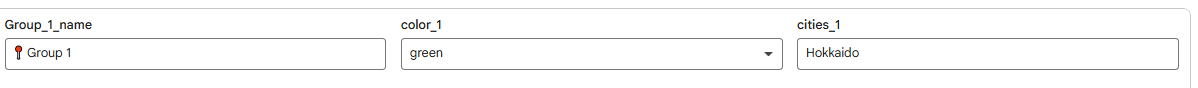

In [20]:
#@title Interactive Location Map { display-mode: "form" }
from geopy.geocoders import ArcGIS
import folium
import time
import json

Group_1_name = "📍 Group 1" #@param {type:"string"}
color_1 = "green" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_1 = "" #@param {type:"string", widget:"textarea"}

Group_2_name = "📍 Group 2" #@param {type:"string"}
color_2 = "blue" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_2 = "" #@param {type:"string", widget:"textarea"}

Group_3_name = "📍 Group 3" #@param {type:"string"}
color_3 = "cadetblue" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_3 = "" #@param {type:"string", widget:"textarea"}

Group_4_name = "📍 Group 4" #@param {type:"string"}
color_4 = "black" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_4 = "" #@param {type:"string", widget:"textarea"}

Group_5_name = "📍 Group 5" #@param {type:"string"}
color_5 = "gray" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_5 = "" #@param {type:"string", widget:"textarea"}

Group_6_name = "📍 Group 6" #@param {type:"string"}
color_6 = "lightgray" #@param ["darkgreen","green","lightgreen","cadetblue","darkblue","blue","lightblue","darkred","red","lightred","pink","orange","purple","darkpurple","black","gray","lightgray"]
cities_6 = "" #@param {type:"string", widget:"textarea"}


def parse_input_cities(raw_text):
    """Extracts a list of locations/cities from any format (JSON or plain list)."""
    text = raw_text.strip()
    if not text:
        return []
    try:
        # if JSON pasted
        parsed = json.loads(text)
        if isinstance(parsed, dict) and "cities" in parsed:
            return parsed["cities"]
        elif isinstance(parsed, list):
            return parsed
    except:
        # 1. First, split the text into clean lines by line breaks
        text = text.replace("\r\n", "\n").replace("\r", "\n")
        raw_lines = text.split("\n")

        # 2. Retain ONLY the lines that DO NOT start with a hashtag '#'
        valid_lines = [line for line in raw_lines if not line.strip().startswith('#')]

       # 3. Join back together and strip any quotation marks
        text = "\n".join(valid_lines)
        text = text.replace("[", "").replace("]", "").replace('"', '').replace("'", "")

        if "\n" in text:
            return [c.strip() for c in text.split("\n") if c.strip()]
        return [c.strip() for c in text.split(",") if c.strip()]
    return []


def create_colored_map(groups_dict):
    geolocator = ArcGIS(timeout=10)

    m = folium.Map(
    location=[30.0, 160.0],
    zoom_start=2,
    tiles='https://{s}.tile.openstreetmap.fr/hot/{z}/{x}/{y}.png',
    attr='&copy; <a href="https://openstreetmap.org">OpenStreetMap</a> contributors'
)

    # make the map gray
    m.get_root().html.add_child(folium.Element("<style>.leaflet-tile-container { filter: grayscale(100%) brightness(110%); }</style>"))

    print("Using ArcGIS service to search for coordinates...\n")

    for group_name, info in groups_dict.items():
        color = info['color']
        cities = info['cities']

        if not cities:
            continue

        print(f"--- Processing group:{group_name} ({color}) ---")
        for city in cities:
            try:
                location = geolocator.geocode(city)
                if location:
                    folium.Marker(
                        location=[location.latitude, location.longitude],
                        popup=f"Group: {group_name}<br>City: {city}",
                        tooltip=city,
                        icon=folium.Icon(color=color, icon='')
                    ).add_to(m)
                    print(f"✅ {city} -> {color}")
                else:
                    print(f"❌ {city} not found")
                time.sleep(0.3)
            except Exception as e:
                print(f"⚠️ Error with {city}: {e}")
                time.sleep(1)
    return m

# Collecting data from the interactive form fields
my_groups = {
    Group_1_name: {"color": color_1, "cities": parse_input_cities(cities_1)},
    Group_2_name: {"color": color_2, "cities": parse_input_cities(cities_2)},
    Group_3_name: {"color": color_3, "cities": parse_input_cities(cities_3)},
    Group_4_name: {"color": color_4, "cities": parse_input_cities(cities_4)},
    Group_5_name: {"color": color_5, "cities": parse_input_cities(cities_5)},
    Group_6_name: {"color": color_6, "cities": parse_input_cities(cities_6)},
}

if any(my_groups[g]["cities"] for g in my_groups):
    map_res = create_colored_map(my_groups)
    display(map_res)
else:
    print("⚠️ All location fields are empty. Please paste your data into at least one field.")

import os
from google.colab import files

# @markdown Enter the output map file name:
output_name = ""  # @param {type:"string"}

download_result_automatically = True  # @param {type:"boolean"}
download_result = download_result_automatically

# Strip accidental whitespace from the edges
output_name = output_name.strip()

# If the field is left completely empty, assign a default name
if not output_name:
    output_name = "my_map.html"
else:
    if not output_name.lower().endswith(".html"):
        output_name += ".html"

# saving results
try:
    map_res.save(output_name)
    print(f"✓ Map successfully saved to Colab disk as '{output_name}'")

    if download_result:
        print(f"⏳ Starting automatic file download {output_name} on your computer...")
        files.download(output_name)

except NameError:
    print("❌ Error: 'map_res' not found!")
except Exception as e:
    print(f"❌ Error while saving: {e}")


Using ArcGIS service to search for coordinates...

--- Processing group:📍 G2c (green) ---
✅ Aichi -> green
✅ Akita -> green
✅ Bangladesh -> green
✅ Beijing -> green
✅ Chelyabinsk region -> green
✅ Chiba -> green
✅ China -> green
✅ Chongming -> green
✅ Ehime -> green
✅ Fukui -> green
✅ Fukuoka -> green
✅ Fukushima -> green
✅ Guangdong -> green
✅ Gunma -> green
✅ Hebei -> green
✅ Henan china -> green
✅ Hiroshima -> green
✅ Hokkaido -> green
✅ Hong Kong -> green
✅ Hyogo -> green
✅ Ibaraki -> green
✅ India -> green
✅ Iwate -> green
✅ Japan -> green
✅ Jiangsu -> green
✅ Jiangxi -> green
✅ Jiujiang -> green
✅ Kagawa -> green
✅ Kagoshima -> green
✅ Kalmykia -> green
✅  Kamchatka Krai Russia -> green
✅ Kanagawa -> green
✅ Khabarovsk -> green
✅ Laos -> green
✅ Mangystau -> green
✅ Miyagi -> green
✅ Miyazaki -> green
✅ Nagasaki -> green
✅ Nepal -> green
✅ Netherlands -> green
✅ Niigata -> green
✅ Novosibirsk region -> green
✅ Okayama -> green
✅ Okinawa -> green
✅ Omsk region -> green
✅ Philippin

✓ Map successfully saved to Colab disk as 'my_map.html'
